In [1]:

import os
import scipy.io
import h5py
import numpy as np
import sys
from scipy import signal as sig
from scipy import stats as stats
import math
import pandas as pd
import csv
import matplotlib.pyplot as plt
from scipy import signal
import seaborn as sns
import logging

%matplotlib widget

scripts_path = '/home/apollo/Documents/github_projects/ripple_sync/scripts/hc_18_scripts/'
data_path = "/media/apollo/projects/hc-18/data/"

os.chdir(scripts_path)

import hc18_BaseFunctions as hc18_bf
import ripple_detection as ripple
import normalizing_functions as norm
import helper_functions as helper
import bootstrapped_estimation as bootstrap
import smoothing_functions as smooth


scripts_path = '/home/apollo/Documents/github_projects/ripple_sync/scripts/hc_11_scripts/'
os.chdir(scripts_path)

import hc11_BaseFunctions as hc11_bf

sessions = ['Achilles_10252013','Buddy_06272013','Cicero_09012014','Gatsby_08022013','Achilles_11012013','Cicero_09102014','Cicero_09172014','Gatsby_08282013']
labels = np.array(['linear','linear','linear','linear','circular','circular','linear','circular'])

rejected_shanks = np.load('rejected_shanks.npy',allow_pickle=True).item()
rejected_electrodes = np.load('rejected_electrodes.npy',allow_pickle=True).item()


In [2]:

# set the font globally
plt.rcParams.update({'font.family':'sans-serif'})
# set the font name for a font family
plt.rcParams.update({'font.sans-serif':'Arial'})
# when saving svg, keep text as text
plt.rcParams['svg.fonttype'] = 'none' 


In [3]:
 
def get_ripple_info(lfp_signal, sampling_rate, ripple_band=(100, 250),ripple_threshold_level = 2, 
                                 min_ripple_duration = 0.02, max_ripple_duration = 0.2, smooth_time = 0.005):
    
    """
    Detects ripples in the LFP data using amplitude envelope and thresholding.

    Parameters
    ----------
    lfp_signal : array_like
        The LFP signal to analyze.
    sampling_rate : float
        Sampling rate of the signal (Hz).
    ripple_threshold_level : float
        Threshold for ripple detection, in units of the standard deviation.
    ripple_low_freq : float
        Lower frequency bound for ripple bandpass filter (Hz).
    ripple_high_freq : float
        Upper frequency bound for ripple bandpass filter (Hz).
    min_ripple_duration : float
        Minimum ripple duration (seconds).
    max_ripple_duration : float
        Maximum ripple duration (seconds).
    smooth_time : float
        Smoothing window (seconds) used in the ripple amplitude envelope.

    Returns
    -------
    ripple_features : dict
        Dictionary containing all ripple properties:
            - 'centers': Indices of center amplitudes for detected ripples.
            - 'powers': Sum of amplitudes for each detected ripple.
            - 'cycles': Indices of samples for each detected ripple.
            - 'minima': Indices of minima in the raw signal for each detected ripple.
            - 'max_amplitudes': Maximum envelope amplitude for each ripple.
    """
    
    filtered_signal = helper.eegfilt(lfp_signal, sampling_rate, ripple_band[0], ripple_band[1])
    envelope = np.abs(helper.hilbert(filtered_signal))

    sigma_points = smooth.get_sigma_points(sigma = smooth_time,sampling_rate = sampling_rate)
    kernel, x_values = smooth.generate_1d_gaussian_kernel(sigma_points)
    smoothed_envelope = smooth.gaussian_smooth_1d(envelope, kernel)


    peak_threshold = np.nanmean(smoothed_envelope) + ripple_threshold_level * np.nanstd(smoothed_envelope)
    # peak_threshold = ripple_threshold_level * np.nanstd(smoothed_envelope)
    
    max_ripple_samples = int(sampling_rate * max_ripple_duration)
    min_ripple_samples = int(sampling_rate * min_ripple_duration)

    peak_indices = helper.detect_peaks(smoothed_envelope, mph=peak_threshold, mpd = min_ripple_samples, edge='rising')

    ripple_features = {
        "centers": [],
        "powers": [],
        "cycles": [],
        "minima": [],
        "max_amplitudes": [],
    }

    one_sd_threshold = np.nanmean(smoothed_envelope) + np.nanstd(smoothed_envelope)
    # one_sd_threshold = np.nanstd(smoothed_envelope)

    for peak_idx in peak_indices:
        start_idx = peak_idx
        while start_idx > 0 and smoothed_envelope[start_idx] > one_sd_threshold:
            start_idx -= 1
    
        end_idx = peak_idx
        while end_idx < len(smoothed_envelope) - 1 and smoothed_envelope[end_idx] > one_sd_threshold:
            end_idx += 1
    
        ripple_window = np.arange(start_idx, end_idx + 1)
        ripple_length = len(ripple_window)
    
        # Check duration constraints
        if ripple_length < min_ripple_samples:
            continue
        elif ripple_length > max_ripple_samples:
            # Trim the ripple window centered around the peak
            half_window = max_ripple_samples // 2
            center_idx = peak_idx
            start_trim = max(center_idx - half_window, 0)
            end_trim = start_trim + max_ripple_samples
            if end_trim >= len(smoothed_envelope):
                end_trim = len(smoothed_envelope) - 1
                start_trim = end_trim - max_ripple_samples
            ripple_window = np.arange(start_trim, end_trim + 1)
            ripple_length = len(ripple_window)
    
        # Use new (possibly trimmed) ripple_window
        center_idx = peak_idx
        min_idx = ripple_window[np.argmin(filtered_signal[ripple_window])]
    
        ripple_features["centers"].append(center_idx)
        ripple_features["powers"].append(np.nansum(envelope[ripple_window]))
        ripple_features["max_amplitudes"].append(np.nanmax(envelope[ripple_window]))
        ripple_features["cycles"].append(ripple_window)
        ripple_features["minima"].append(min_idx)


    return ripple_features


In [4]:

def get_ripple_info_AmpEnvMethod(ripple_lfp,srate,ripple_threshold_level,ripple_low_freq,ripple_high_freq,minimum_ripple_length,smooth_time):

    import os
    import numpy as np
    import scipy.io
    import hc11_BaseFunctions as bf11


    ripple = helper.eegfilt(ripple_lfp, srate,ripple_low_freq, ripple_high_freq)
    ripple_amp = np.abs(helper.hilbert(ripple))

    sigma_points = smooth.get_sigma_points(sigma = smooth_time,sampling_rate = srate)
    kernel, x_values = smooth.generate_1d_gaussian_kernel(sigma_points)
    ripple_amp_smooth = smooth.gaussian_smooth_1d(ripple_amp, kernel)


    Ripple_Transitions = np.diff((ripple_amp_smooth > ripple_threshold_level*np.nanstd(ripple_amp_smooth)).astype(int))
    # it detects different true false sequences
    if np.all(Ripple_Transitions==0):
        All_Ripples_CenterAmp = []
        All_Ripples_Power = []
        All_Ripples_Cycles = []
        All_Ripples_MaxPeaks = []
        
    else:

        potential_ripple_cycle_beg = np.where(Ripple_Transitions == 1)[0]
        potential_ripple_cycle_end = np.where(Ripple_Transitions == -1)[0]

        # check if first element is 1:
        if potential_ripple_cycle_beg[0] > potential_ripple_cycle_end[0]:
            potential_ripple_cycle_end = potential_ripple_cycle_end[1:].copy()

        if potential_ripple_cycle_beg[-1] > potential_ripple_cycle_end[-1]:
            potential_ripple_cycle_beg = potential_ripple_cycle_beg[0:-1].copy()

        if potential_ripple_cycle_beg.shape[0] == potential_ripple_cycle_end.shape[0]:
            print('Seems fine! Same shape!')
        else:
            print('There is something wrong with their shapes.')

        All_Ripples_CenterAmp = []
        All_Ripples_Power = []
        All_Ripples_Cycles = []
        All_Ripples_MaxPeaks = []
        for ii in range(0,potential_ripple_cycle_beg.shape[0]):
            pre_ripple_cyc = np.arange(potential_ripple_cycle_beg[ii],potential_ripple_cycle_end[ii])
            if len(pre_ripple_cyc) > minimum_ripple_length:
                All_Ripples_MaxPeaks.append(pre_ripple_cyc[np.argmax(ripple[pre_ripple_cyc])])
                All_Ripples_CenterAmp.append(pre_ripple_cyc[np.argmax(ripple_amp[pre_ripple_cyc])])
                All_Ripples_Power.append(np.sum(ripple_amp[pre_ripple_cyc]))
                All_Ripples_Cycles.append(pre_ripple_cyc)

            
    return All_Ripples_CenterAmp,All_Ripples_Power,All_Ripples_Cycles,All_Ripples_MaxPeaks


In [6]:

output_dict = dict()
output_dict['rat'] = []
output_dict['session'] = []
output_dict['side'] = []
output_dict['state'] = []
output_dict['shank'] = []
output_dict['ripple_length'] = []
output_dict['ripple_counts'] = []
output_dict['ripple_max_amp'] = []

srate = 1250.
# ripple_threshold_level = 2
# ripple_low_freq = 100
# ripple_high_freq = 250
# minimum_ripple_length = 0.03*srate
# smooth_points = 0.001*srate

states = ['pre','post']
for session in sessions:

    print(session)
    logging.info('session = ' + str(session))
    
    all_shanks,left_shanks,right_shanks = hc11_bf.get_shanks_info(session)
    LFP,srate,SWS,SWS_lfp_index,SWS_lfp_index_pre,SWS_lfp_index_pos = hc11_bf.load_lfp_hc11_data(session)
    # spike_times,spike_ids,pyr_ids,int_ids = hc11_bf.load_spikes_hc11_data(RatName)
        
    os.chdir(scripts_path)
    all_shanks_electrode_position = np.load(f'electrode_position_{session}.npy')

    all_shanks_distance_to_ref = np.arange(0,(len(all_shanks)/2)*200,200)
    all_shanks_distance_to_ref = np.concatenate([all_shanks_distance_to_ref,all_shanks_distance_to_ref])
    accepted_shanks = np.setdiff1d(np.arange(len(all_shanks)),rejected_shanks[session])

    for state in states:
        if state == 'pre':
            lfp_index = SWS_lfp_index_pre[-int(30*60*srate):]
            # lfp_index = SWS_lfp_index_pre[0:int(30*60*srate)]
        elif state == 'post':
            lfp_index = SWS_lfp_index_pos[0:int(30*60*srate)]
                
        # for shank_1_idx in [0]:
        for shank_1_idx in np.arange(0,len(accepted_shanks)):    
            
            shank_1 = accepted_shanks[shank_1_idx]
            print('Shank 1 = ' + str(shank_1))
    
    
            Imaxripple = np.where(all_shanks_electrode_position[shank_1]==0)[0][0]
            shanks = all_shanks[shank_1]
            ripple_lfp_1 = LFP[shanks[Imaxripple],lfp_index].copy()
                
            All_Ripples_CenterAmp,All_Ripples_Power,All_Ripples_Cycles,All_Ripples_MaxPeaks = get_ripple_info_AmpEnvMethod(ripple_lfp_1,srate,ripple_threshold_level = 2,ripple_low_freq = 100, ripple_high_freq = 250, minimum_ripple_length = 0.03*srate, smooth_time = 0.001)
            ripple_counts = len(All_Ripples_MaxPeaks)/(lfp_index.shape[0]/srate)
            ripple_length = []
            for cyc in All_Ripples_Cycles:
                ripple_length.append(cyc.shape[0]/srate)
            ripple_length = np.nanmean(ripple_length)
            ripple_max_amp = np.nanmean(All_Ripples_Power)
            print(ripple_counts)


            # ripple_features = get_ripple_info(ripple_lfp_1, srate, ripple_band=(100, 250),ripple_threshold_level = 2, 
            #                                  min_ripple_duration = 0.03, max_ripple_duration = 0.5, smooth_time = 0.001)
            # ripple_length = []
            # for cyc in ripple_features['cycles']:
            #     ripple_length.append(cyc.shape[0]/srate)
            # ripple_length = np.nanmean(ripple_length)
            # ripple_counts = len(ripple_features['centers'])/(lfp_index.shape[0]/srate)
            # ripple_max_amp = np.nanmean(ripple_features['max_amplitudes'])
            # print(ripple_counts)

            if (shank_1 in left_shanks):
                side = 'left'
            else:
                side = 'right'
                
            output_dict['rat'].append(session[0:3])
            output_dict['session'].append(session)
            output_dict['side'].append(side)
            output_dict['state'].append(state)
            output_dict['shank'].append(shank_1)
            output_dict['ripple_length'].append(ripple_length)
            output_dict['ripple_counts'].append(ripple_counts)
            output_dict['ripple_max_amp'].append(ripple_max_amp)

df = pd.DataFrame(output_dict)
df
path = "/home/apollo/Documents/github_projects/ripple_sync/results/"
os.chdir(path)

df.to_csv('Figure_Ripple_Features_PrePost_2.csv',index=False)


Achilles_10252013
Shank 1 = 0
Seems fine! Same shape!
0.51
Shank 1 = 1
Seems fine! Same shape!
0.5094444444444445
Shank 1 = 2
Seems fine! Same shape!
0.4861111111111111
Shank 1 = 3
Seems fine! Same shape!
0.4855555555555556
Shank 1 = 4
Seems fine! Same shape!
0.46944444444444444
Shank 1 = 5
Seems fine! Same shape!
0.48277777777777775
Shank 1 = 6
Seems fine! Same shape!
0.5133333333333333
Shank 1 = 7
Seems fine! Same shape!
0.5333333333333333
Shank 1 = 8
Seems fine! Same shape!
0.5316666666666666
Shank 1 = 9
Seems fine! Same shape!
0.5411111111111111
Shank 1 = 10
Seems fine! Same shape!
0.5377777777777778
Shank 1 = 11
Seems fine! Same shape!
0.5144444444444445
Shank 1 = 0
Seems fine! Same shape!
0.5594444444444444
Shank 1 = 1
Seems fine! Same shape!
0.525
Shank 1 = 2
Seems fine! Same shape!
0.5283333333333333
Shank 1 = 3
Seems fine! Same shape!
0.5416666666666666
Shank 1 = 4
Seems fine! Same shape!
0.5422222222222223
Shank 1 = 5
Seems fine! Same shape!
0.5283333333333333
Shank 1 = 6
See

In [3]:


def confidence_interval(data, confidence=0.95, axis=None):
    """
    Calculate the confidence interval for the mean of a dataset along a specified axis.

    Parameters:
    - data (array-like): The dataset for which to calculate the confidence interval.
    - confidence (float): The confidence level for the interval (default is 0.95).
    - axis (int, optional): The axis along which to calculate the mean and confidence interval. 
                            If None, the data is flattened.

    Returns:
    - (ndarray, ndarray): The lower and upper bounds of the confidence interval.
    """
    data = np.array(data)
    n = data.shape[axis] if axis is not None else len(data)
    mean = np.nanmean(data, axis=axis)
    se = stats.sem(data, axis=axis, nan_policy='omit')  # Standard error of the mean

    if n > 30:
        # Use z-score for large samples
        h = se * stats.norm.ppf((1 + confidence) / 2)
    else:
        # Use t-score for small samples
        h = se * stats.t.ppf((1 + confidence) / 2, n - 1)
    
    return mean - h, mean + h




In [4]:
path = "/home/apollo/Documents/github_projects/ripple_sync/results/"
os.chdir(path)

filename = 'Figure_Ripple_Features_PrePost_2.csv'
df = pd.read_csv(filename)

# Set reference categories
# df['side'] = pd.Categorical(df['side'], categories=['ipsi', 'contra'], ordered=True)
# df['state'] = pd.Categorical(df['state'], categories=['pre', 'post'], ordered=True)
df


,rat,session,side,state,shank,ripple_length,ripple_counts,ripple_max_amp
0,Ach,Achilles_10252013,left,pre,0,0.047400,0.510000,26223.172117
1,Ach,Achilles_10252013,left,pre,1,0.047252,0.509444,24102.975853
2,Ach,Achilles_10252013,left,pre,2,0.047123,0.486111,23703.766718
3,Ach,Achilles_10252013,left,pre,3,0.047401,0.485556,23396.996930
4,Ach,Achilles_10252013,left,pre,4,0.047286,0.469444,20934.479663
...,...,...,...,...,...,...,...,...
175,Gat,Gatsby_08282013,left,post,6,0.042543,0.500556,11844.732260
176,Gat,Gatsby_08282013,right,post,12,0.045242,0.606667,10430.118654
177,Gat,Gatsby_08282013,right,post,13,0.045766,0.596111,11966.655632
178,Gat,Gatsby_08282013,right,post,14,0.045667,0.640556,14687.859598


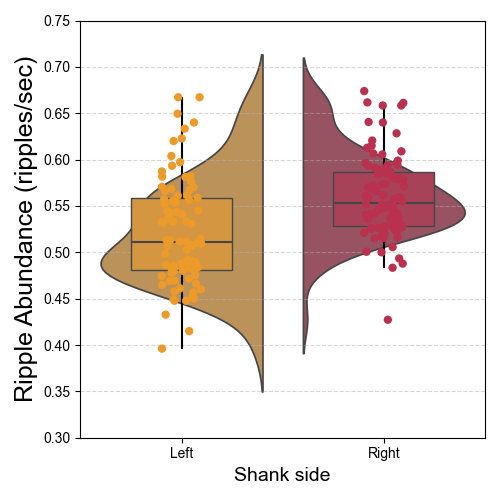

In [5]:

plt.close('all')
plt.figure(figsize=(5,5))

my_pal ={"pre": "#ec9a29","post":"#b9314f"}

sns.stripplot(data=df, x="state",hue="state",y="ripple_counts", order=["pre", "post"],
              palette=my_pal,size=6,legend=False,alpha=1)
# sns.pointplot(data=df,x='shank_side',hue="shank_side",y='ripple_abundance', order=["left", "right"],
#               estimator='median',errorbar=("pi",50), palette=my_pal,capsize=0, linestyle='none',
#               err_kws={'linewidth': 6},linewidth=2,markersize=10)

# # Create the boxplot
box = sns.boxplot(data=df, x='state', hue="state", y='ripple_counts',
            order=["pre", "post"], showfliers=False, showcaps=False,fill=True,legend=False,
            whiskerprops=dict(linestyle='-', linewidth=1.5, color='black'),
            medianprops=dict(linestyle='-', linewidth=1.5),
            width=0.5, palette=my_pal)  # Using the custom color palette

sns.violinplot(data=df,x='state', hue="state",order=["pre", "post"], y='ripple_counts',palette=my_pal,
               fill=True,inner = None,split=True, density_norm='width',saturation=0.5,legend=False)

plt.ylabel('Ripple Abundance (ripples/sec)',fontsize=18)
plt.xlabel('Shank side',fontsize=14)
plt.grid(linestyle='--',alpha=0.5,axis='y')
plt.legend([], [], frameon=False)

# we need to set it manually so we will be able to edit them ticks in inkscape as a path (otherwise, we need to set it as a "object to path")
plt.xticks([0,1],labels=['Left','Right'])
plt.yticks(np.arange(0.3,0.8,0.05))

plt.tight_layout()



os.chdir(scripts_path + '/figures/')
fig_name = 'Figure_Ripple_Counts_PrePost_Pooled.svg'
# plt.savefig(fig_name,transparent=False,format='svg', bbox_inches = 'tight')
plt.show()
# helper.delete_clip_path(fig_name)




In [6]:
import statsmodels.api as sm

# Define the formula for the mixed-effects model
formula = "ripple_counts ~ C(state, Treatment(reference='pre'))"
re_formula = "1"
vc_formula = {"session": "0 + session"}
# Fit the mixed-effects model
model = sm.MixedLM.from_formula(formula, re_formula=re_formula, vc_formula=vc_formula, data=df,groups='rat')
result = model.fit()

# Print summary of the model
print(result.summary())


                        Mixed Linear Model Regression Results
Model:                     MixedLM          Dependent Variable:          ripple_counts
No. Observations:          180              Method:                      REML         
No. Groups:                4                Scale:                       0.0015       
Min. group size:           18               Log-Likelihood:              313.7659     
Max. group size:           72               Converged:                   Yes          
Mean group size:           45.0                                                       
--------------------------------------------------------------------------------------
                                             Coef. Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------------------------------
Intercept                                    0.523    0.014 37.265 0.000  0.495  0.550
C(state, Treatment(reference='pre'))[T.post] 0.039    0.006  6.861 0

/home/apollo/.pyenv/versions/3.13.5/envs/ripple_sync/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [14]:
result.pvalues

Intercept                                       5.976150e-304
C(state, Treatment(reference='pre'))[T.post]     6.855957e-12
rat Var                                          8.776103e-01
session Var                                      1.744543e-01
dtype: float64

In [7]:
import bootstrapped_estimation as bootstrap

ripple_counts_pre = []
ripple_counts_post = []
for animal in sessions:
    df_slice = df[df['session'] == animal]
    ripple_counts_pre.append(df_slice[df_slice['state'] == 'pre']['ripple_counts'].values)
    ripple_counts_post.append(df_slice[df_slice['state'] == 'post']['ripple_counts'].values)
ripple_counts_pre = np.concatenate(ripple_counts_pre)
ripple_counts_post = np.concatenate(ripple_counts_post)



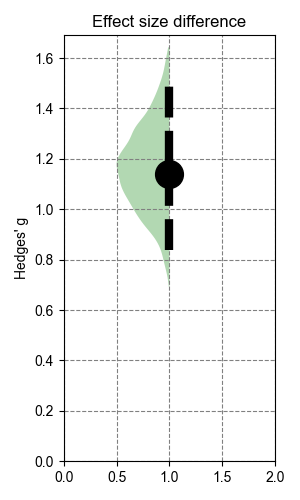

In [8]:

observed_g = bootstrap.hedges_g(ripple_counts_post,ripple_counts_pre, paired=True)

bootstrapped_g, ci_bounds = bootstrap.bootstrap_hedges_g(ripple_counts_post,ripple_counts_pre, n_bootstraps=5000, ci=95, paired=True)

observed_g, shuffled_g, p_value = bootstrap.pvalue_hedges_g_permutation(ripple_counts_post,ripple_counts_pre, n_permutations=5000, ci=95, paired=True)


# Compute Q1 (25th percentile) and Q3 (75th percentile)
Q1 = np.percentile(bootstrapped_g, 25)
Q3 = np.percentile(bootstrapped_g, 75)

# Compute interquartile range (IQR)
IQR = Q3 - Q1

# Define outlier boundaries
lower_bound = Q1 - 1.5 * IQR  # Anything below this is an outlier
upper_bound = Q3 + 1.5 * IQR  # Anything above this is an outlier

lower_bound = np.nanmin([Q1 - 1.5 * IQR,np.percentile(bootstrapped_g, 2.5)])
upper_bound = np.nanmax([Q3 + 1.5 * IQR,np.percentile(bootstrapped_g, 97.5)])

# Filter out outliers
filtered_g_values = [g for g in bootstrapped_g if lower_bound <= g <= upper_bound]

plt.figure(figsize=(3,5))
violin_parts = plt.violinplot(filtered_g_values,showmeans=False,showextrema=False,side='low',positions=[1],widths=1)
for pc in violin_parts['bodies']:
    pc.set_facecolor('green')
# plt.boxplot(filtered_g_values,positions=[2])
   
plt.plot([1,1],ci_bounds,color='black',lw=6,ls='--')
plt.plot(1,observed_g,color='black',ls='',marker='o',markersize=20)
plt.plot()
plt.ylabel("Hedges' g")
plt.grid(ls='--',color='gray')
plt.xlim([0,2])
# plt.ylim([0,3.5])
plt.ylim(bottom=0)
plt.title('Effect size difference')
plt.tight_layout()

os.chdir(scripts_path + '/figures/')
fig_name = 'Figure_Ripple_Counts_PrePost_EffectSize.svg'

# plt.savefig(fig_name,transparent=False,format='svg', bbox_inches = 'tight')
plt.show()
# helper.delete_clip_path(fig_name)


In [12]:
states = ['pre','post']
mean_ripple_counts = []
for session in sessions:
    state_aux = []
    df_session = df['session'] == session
    for state in states:
        
        df_state = df['state'] == state
        state_aux.append(np.nanmean(df['ripple_counts'][df_session*df_state].values))
    mean_ripple_counts.append(state_aux)
mean_ripple_counts = np.array(mean_ripple_counts)
mean_ripple_counts = np.transpose(mean_ripple_counts)
mean_ripple_counts



array([[0.50958333, 0.53771605, 0.49268519, 0.595     , 0.48185185,
        0.56587963, 0.46800926, 0.53222222],
       [0.53967593, 0.55530864, 0.55689815, 0.6219697 , 0.53481481,
        0.58726852, 0.52935185, 0.56188889]])

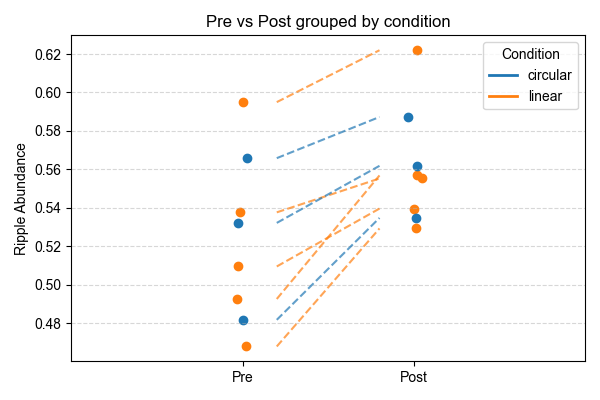

In [13]:
labels = np.array(['linear','linear','linear','linear','circular','circular','linear','circular'])

# Step 1: assign unique colors to each label
unique_labels = np.unique(labels)
cmap = plt.get_cmap('tab10')  # categorical colormap
color_map = {lab: cmap(i) for i, lab in enumerate(unique_labels)}

# Step 2: plot
plt.figure(figsize=(6, 4))
x_coords = [0.2, 0.8]

for i in range(mean_ripple_counts.shape[1]):
    lab = labels[i]
    color = color_map[lab]
    # Line between paired points
    plt.plot(x_coords, mean_ripple_counts[:, i], color=color, linestyle='--', alpha=0.7)
    # Plot dots
    jitter_strength = 0.02  # Adjust the strength of jitter
    x_values = np.random.randn(1) * jitter_strength
    plt.scatter(0+x_values, mean_ripple_counts[0, i], color=color, edgecolor=color)
    
    jitter_strength = 0.02  # Adjust the strength of jitter
    x_values = np.random.randn(1) * jitter_strength
    plt.scatter(1+x_values, mean_ripple_counts[1, i], color=color, edgecolor=color)

# Step 3: legend for labels
handles = [plt.Line2D([0], [0], color=color_map[lab], lw=2) for lab in unique_labels]
plt.legend(handles, unique_labels, title='Condition', bbox_to_anchor=(1, 1))
plt.grid(linestyle='--',alpha=0.5,axis='y')

# Aesthetic touches
plt.xticks([0, 1], ['Pre', 'Post'])
plt.xlim([-1, 2])
# plt.ylim([0.5, 1.1])
plt.ylabel('Ripple Abundance')
plt.title('Pre vs Post grouped by condition')
plt.tight_layout()


os.chdir(scripts_path + '/figures/')
fig_name = 'Figure_Ripple_Counts_PrePost.svg'
# plt.savefig(fig_name,transparent=False,format='svg', bbox_inches = 'tight')
plt.show()
# helper.delete_clip_path(fig_name)



In [21]:
stats.ttest_rel(mean_ripple_counts[1,:],mean_ripple_counts[0,:])

TtestResult(statistic=np.float64(5.806657267709599), pvalue=np.float64(0.0006590457660079895), df=np.int64(7))

In [20]:
np.nanmean(mean_ripple_counts[1,:]-mean_ripple_counts[0,:])

np.float64(0.0380286195286195)

In [22]:

diff_counts = np.squeeze(np.diff(mean_ripple_counts,axis=0))
diff_counts


array([0.03009259, 0.01759259, 0.06421296, 0.0269697 , 0.05296296,
       0.02138889, 0.06134259, 0.02966667])

In [23]:
labels = np.array(['linear','linear','linear','linear','circular','circular','linear','circular'])
circ_idx = labels == 'circular'

In [25]:
ci_lower,ci_upper

(np.float64(0.022542360938496382), np.float64(0.05351487811874262))

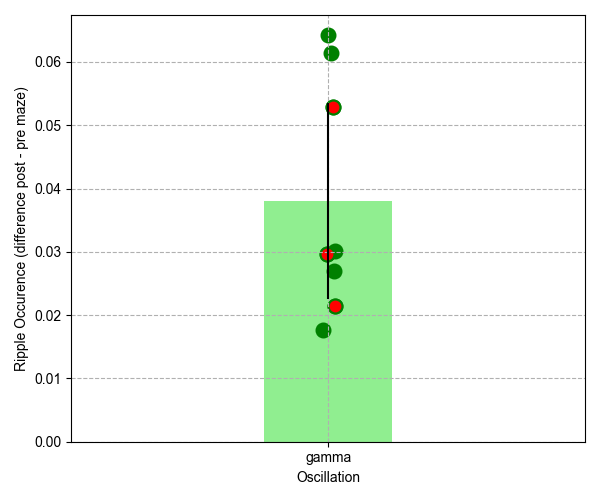

In [24]:

mean_diff = np.nanmean(diff_counts, axis=0)
std_diff = np.nanstd(diff_counts, axis=0)
ci_lower,ci_upper = confidence_interval(diff_counts,confidence=0.95)
errors_ = (ci_upper - ci_lower) / 2

plt.figure(figsize=(6,5))
plt.bar(0, mean_diff, yerr=errors_,color='lightgreen',width = 0.5)

jitter_strength = 0.02  # Adjust the strength of jitter
x_values = np.random.randn(diff_counts.shape[0]) * jitter_strength
plt.scatter(x_values,diff_counts, color='green', alpha=1, edgecolors='green', s=100,linewidths=1.5)

plt.scatter(x_values[circ_idx],diff_counts[circ_idx], color='red', alpha=1, edgecolors='green', s=100,linewidths=1.5)

plt.plot([0.2],[mean_diff],'g--')

plt.xticks([0],labels=['gamma'])
plt.xlabel('Oscillation')
# plt.ylim([-1,1])
plt.xlim([-1,1])

plt.ylabel('Ripple Occurence (difference post - pre maze)')
plt.title('')
plt.grid(True, which="both", ls="--")
plt.tight_layout()
    
os.chdir(scripts_path + '/figures/')
fig_name = 'Figure_Ripple_Counts_PrePost_Diff.svg'
# plt.savefig(fig_name,transparent=False,format='svg', bbox_inches = 'tight')
plt.show()
# helper.delete_clip_path(fig_name)

